## Lenses

### Lens equation
Lenses are a specific shape of medium that either con- or diverge incoming parallel light rays. This happens because of the refractions on its two circular surfaces. Biconvec lenses converge, biconcave ones diverge.
#### Thin lenses
For thin enough lenses we can approximate the two refractions as happening in the same point.
From this and some transformations that can be seen in the theory script, we get the follwoing equation for concave thin lenses:
$$\frac 1 f = \frac 1 {d_o} + \frac 1 {d_i}$$
where $f$ is the focal point's distance to the lens, $d_o$ is the original object's distance and $d_1$ is the images distance.

#### Graphing $d_i$ vs. $d_o$

*Describe what you expect.*

In [68]:
import numpy as np

# add code to define arrays with data
#xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 17.7, 13.9, 9, 35, 39, 11, 74.2])
#xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 55.8, 50, 79.9, 79.9, 58, 25, 110.7])
#xi = np.array([49.7, 58, 54, 62.3, 95.6, 58.5, 64, 91.5, 92.4, 78.6, 59.5, 121.3])
xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 13.9, 35, 39, 11])
xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 50, 79.9, 58, 25])
xi = np.array([49.7, 58, 54, 62.3, 95.6, 64, 92.4, 78.6, 59.5])

di = xi - xl
print(di)
do = xl - xo

ddi = 2 * 0.5
ddo = 2 * 0.2

[16.7 28.3 14.5 38.8 52.9 14.  12.5 20.6 34.5]


r^2 = 0.9797
Focal length f = 9.8075 ± 0.0597
t = 164.3251
p-value = 2.2204e-15


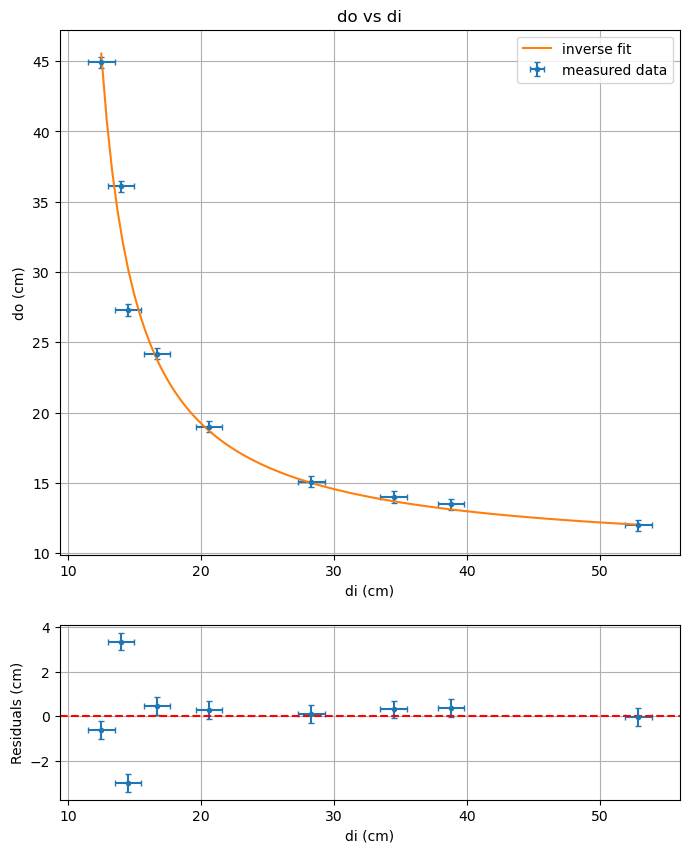

In [69]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def model(x, f):
    return 1/(1/f - 1/x)


# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(model, di, do)
f_lin = coeff[0] 
df_lin = np.sqrt(np.diag(pcov))[0]

# calculate do^2
do_pred = model(di, f_lin)

ss_res = np.sum((do - do_pred) ** 2)              # residual sum of squares
ss_tot = np.sum((do - np.mean(do)) ** 2)          # total sum of squares

r2 = 1 - (ss_res / ss_tot)

print(f"r^2 = {r2:.4f}")

from scipy import stats

# number of data points and parameters
n = len(do)
p = 1  # f and R0

# t-statistic for slope
t_stat = f_lin / df_lin

# degrees of freedom
dof = n - p

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), dof))

print(f"Focal length f = {f_lin:.4f} ± {df_lin:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")



# calculate fitted values and residuals
di_range = np.linspace(min(di), max(di), 100)
do_fit = model(di_range, f_lin)

res_lin = do - model(di, f_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(di, do, xerr=ddi, yerr=ddo, fmt='.', capsize=2, label='measured data')
ax1.plot(di_range, do_fit, label='inverse fit')
ax1.set_title('do vs di')
ax1.set_xlabel('di (cm)')
ax1.set_ylabel('do (cm)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(di, res_lin, xerr=ddi, yerr=ddo, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('di (cm)')
ax2.set_ylabel('Residuals (cm)')
ax2.grid(True)
plt.show()


#### Grpahing $\frac{1}{d_i}$ vs. $\frac{1}{d_o}$
*Describe how the refractive index can be found from the fit parameter.*

In [61]:
# add code to calculate and print the refractive index here

#### Graphing $d_i \cdot d_o$ vs. $d_i + d_o$

*Describe what you expect.*

In [ ]:
# add code to graph the data and fit here (with residual plot)

##### Discussion
*Derive the focal length from the fit parameters of the three graphs and discuss the results*

In [62]:
# add code to calculate and print the refractive index here

#### Two Lenses

*Calculate the predicted position and size of the image and compare with experimental data*

In [64]:
# add data and code here